<a href="https://colab.research.google.com/github/profemathdata/profemathdata-portfolio.github.io/blob/main/ElasticNet_final2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#######teoria lasso y elastic net
#https://mbrenndoerfer.com/writing/elastic-net-regularization-complete-guide-mathematical-foundations-python-implementation


**ELASTIC NET**

La Regresion Elastic Net es un Método propuesto por Zuo y Hastie (2005) para regularizar y a la vez de seleccionar variables mediante la minimización del error cuadrático sujeto a una restricción que pondera la penalización L1 referente a LASSO y la penalización L2 referente a Ridge.

$$ \min_{\beta} \{\sum_{i=1}^{n} (y_{i}-[\beta_{0}+\sum_{j=1}^{p}\beta_{j}X_{ij}])^2\}$$

sujeta a la restricción

$$\lambda_{1} \sum_{j=1}^{p}|\beta_{j}|+\lambda_{2} \sum_{j=1}^{p}\beta_{j}^2
<s$$

donde: $\lambda_{1}$ y $\lambda_{2}$ son parámetros ajustables no negativos, la función de $\lambda_{1}$ es conseguir modelosparsimoniosos mientras que $\lambda_{2}$ promueve que variables altamente correlacionadas
 tengan coeficientes similares.De forma equivalente la restricción se puede reescribir como:

$$(1-\alpha) \sum_{j=1}^{p}|\beta_{j}|+  \alpha \sum_{j=1}^{p}\beta_{j}^2
<s$$


donde: $\alpha =\frac{\lambda_{2}}{\lambda_{1}+\lambda_{2}}$, es de notar que con $\alpha=1$ se aplica Regresión Ridge, con $\alpha = 0$ se aplica Regresión LASSO.


In [36]:
import numpy as np #estructura de datos
import pandas as pd #operaciones matematicas
import statsmodels.api as sm #modelos estdisticos
from sklearn.preprocessing import StandardScaler #estandarizacion de variables
from sklearn.metrics import root_mean_squared_error #funcion para medir precision del modelo
from sklearn.model_selection import train_test_split #funcion para extaer una miestra

#Gráficos
#configuración de gráficos
# ==============================================================================
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 8
import seaborn as sns


#funciones especiales
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import enet_path
from matplotlib.animation import FuncAnimation, FFMpegWriter



In [87]:
def alpha_op(modelo):
    # 1. Identificar el índice del l1_ratio óptimo (Tal como lo hiciste al graficar)
    # Buscamos dónde está el l1_ratio seleccionado dentro de la lista de ratios probados
    idx_ratio_optimo = np.where(modelo.l1_ratio == modelo.l1_ratio_)[0][0]

    # 2. Extraer los MSE para ese ratio específico (Matriz ahora es de n_alpha, n_folds)
    mse_folds = modelo.mse_path_[idx_ratio_optimo]
    alphas = modelo.alphas_

    # 3. Calcular promedio y desviación estándar por filas (axis=1 es a través de los folds)
    mse_promedio = np.mean(mse_folds, axis=1)
    mse_sd       = np.std(mse_folds, axis=1)

    rmse_cv = np.sqrt(mse_promedio)
    rmse_sd = np.sqrt(mse_sd)

    # 4. Encontrar el Alfa Óptimo Absoluto
    idx_optimo = np.argmin(rmse_cv)
    alfa_optimo  = alphas[idx_optimo].item()

    # 5. Regla de la 1 Desviación Estándar (1-SE Rule)
    rmse_optimo = rmse_cv[idx_optimo]
    limite_1sd  = rmse_optimo + rmse_sd[idx_optimo]

    # Buscamos los alfas cuyo error sea menor al límite tolerado
    # Como en Scikit-Learn los alphas vienen de mayor a menor,
    # el "más parsimonioso" (el que descarta más variables) es el ALFA MÁS GRANDE.
    alphas_validos = alphas[rmse_cv <= limite_1sd]

    # Tomamos el máximo de los válidos
    alfa_op_1sd = np.max(alphas_validos).item() if len(alphas_validos) > 0 else alpha_op
    print(f"Alpha Mínimo: {alfa_optimo:.6f}")
    print(f"Alpha 1-SD: {alfa_op_1sd:.6f} (Este descartará más variables)")

    return [alfa_optimo, alfa_op_1sd]

In [38]:
# Número de predictores incluidos (coeficiente !=0) en función de alpha
# ==============================================================================
def graf_cant_coef_alpha_en(alphas_path,coefs_path, alpha_op_en,best_ratio):
  # 1. Calculamos cuántas variables son distintas de cero para cada alpha
  # coefs_path tiene forma (n_features, n_alphas)
  # Contamos cuántos coeficientes != 0 en cada columna (axis=0)
  n_variables_activas = np.sum(coefs_path != 0, axis=0)

  # 2. Creamos la gráfica
  plt.figure(figsize=(10, 4))

  # Graficamos el conteo

  plt.plot(alphas_path, n_variables_activas, color='teal', lw=2)
  # Añadimos las líneas de referencia que ya conocemos
  plt.axvline(alpha_op_en, color='black', linestyle='--',
              label=f'Alpha Óptimo: {alpha_op_en:.2e}')

  # Si calculaste el alpha_1sd o el parsimonioso, añádelo aquí:
    # Configuración de ejes
  plt.xscale('log')
  plt.xlabel('Alpha (Regularización)')
  plt.ylabel('Nº de Variables en el Modelo')
  plt.title(f'Parsimonia del Modelo (L1 Ratio: {best_ratio:.2f})')
  plt.grid(True, which="both", alpha=0.3)
  plt.legend()

  # Invertir el eje si prefieres ver el aumento de regularización hacia la derecha
  plt.xlim(min(alphas_path),max(alphas_path))

  plt.show()

  return

In [39]:
def graf_coef_alpha_en(mod_EN,coef_path, alpha_op_en):

  # Graficar
  #plt.figure(figsize=(12, 7))
  fig, ax = plt.subplots(figsize=(10, 3))
  ax.plot(alphas_path, coefs_path.T)
  ax.axvline(alpha_op_en, color='green', linestyle=':', label=f'Alpha 1-SD: {alpha_op_en:.4f}')
  ax.set_xscale('log')
  ax.set_xlabel('alpha')
  ax.set_ylabel('coeficientes')
  ax.set_title(f'Coeficientes del modelo (Elastic Net con l1_ratio={best_ratio:.2f})');
  plt.grid(True)
  plt.show()

  return


In [40]:
def graf_mse_alpha_en(mod_EN,alpha_op_en):
  # 1. Identificar el índice del l1_ratio óptimo
  # model_cv.l1_ratio es la lista de ratios que probaste
  idx_ratio_optimo = np.where(mod_EN.l1_ratio == mod_EN.l1_ratio_)[0][0]

  # 2. Extraer los MSE para ese ratio específico
  # mse_path_ tiene forma (n_l1_ratio, n_alpha, n_folds)
  mse_folds = mod_EN.mse_path_[idx_ratio_optimo] # Esto nos da (n_alpha, 5)
  alphas = mod_EN.alphas_

  # 3. Graficar cada fold por separado
  plt.figure(figsize=(10, 6))

  colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

  for i in range(5):
  #    plt.plot(-np.log10(alphas), mse_folds[:, i],
  #             label=f'Fold {i+1}', color=colores[i], alpha=0.7, linestyle='--')
      plt.plot(alphas, mse_folds[:, i],
              label=f'Fold {i+1}', color=colores[i], alpha=0.7, linestyle='--')

  # 4. Agregar el promedio para comparar
  mse_promedio = np.mean(mse_folds, axis=1)
  #plt.plot(-np.log10(alphas), mse_promedio,
  #         label='Promedio (Global)', color='black', linewidth=3)
  plt.plot(alphas, mse_promedio,
          label='Promedio (Global)', color='black', linewidth=3)

  # 5. Marcar el Alpha óptimo

  plt.axvline(alpha_op_en, color='black', linestyle=':', label='Alpha Óptimo')
  plt.title(f'Variabilidad del MSE entre Folds (l1_ratio = {mod_EN.l1_ratio_})')
  plt.xscale('log')
  plt.xlabel('Alpha')
  plt.ylabel('MSE')
  plt.xlim(min(alphas),max(alphas))
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()
  return

In [41]:
def conteo_mod_EN_post(alpha_op_en, alphas_path, coefs_path, X_train):
    # 1. Encontrar el índice del alpha más cercano en el path
    # Esto es necesario porque el path tiene sus propios valores de alpha
    idx = (np.abs(alphas_path - alpha_op_en)).argmin()

    # 2. Extraer los coeficientes usando ese índice
    coeficientes = coefs_path[:, idx]
    nombres_variables = X_train.columns

    # 3. Identificar variables con coeficiente distinto de cero
    # Usamos un umbral pequeño (1e-10) por precisión numérica
    mask_activos = np.abs(coeficientes) > 1e-10
    variables_seleccionadas = nombres_variables[mask_activos]

    print(f"--- Resultados del Modelo Elastic Net (l1_ratio=0.99) ---")
    print(f"Alpha buscado: {alpha_op_en:.6f}")
    print(f"Alpha más cercano en el path: {alphas_path[idx]:.6f}")
    print(f"Número de variables originales: {len(nombres_variables)}")
    print(f"Número de variables finales: {len(variables_seleccionadas)}")
    print(f"\nVariables que sobrevivieron a la purga:")
    print(list(variables_seleccionadas))
    return

    #return variables_seleccionadas.tolist()

In [7]:
def conteo_mod_EN_prio(alpha_op_en,mod_EN, X_train):
  # 2. Identificar qué variables quedaron (Coeficientes != 0)
  coeficientes = mod_EN.coef_
  nombres_variables = X_train.columns
  variables_seleccionadas = nombres_variables[coeficientes != 0]

  print(f"--- Resultados del Modelo Elastic Net (l1_ratio=0.99) ---")
  print(f"Alpha óptimo: {alpha_op_en:.6f}")
  print(f"Número de variables originales: {len(nombres_variables)}")
  print(f"Número de variables finales: {len(variables_seleccionadas)}")
  print(f"\nVariables que sobrevivieron a la purga:")
  print(list(variables_seleccionadas))
  return

In [42]:
def resumen_final(mod_EN_final):
  # 3. Realizar predicciones sobre el set de TEST
  # IMPORTANTE: X_test debe estar estandarizado con el MISMO scaler que X_train
  y_pred = mod_EN_final.predict(X_test)

  # 4. Evaluar el desempeño
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  r2 = r2_score(y_test, y_pred)

  print(f"--- Desempeño del Modelo Final en Test ---")
  print(f"RMSE: {rmse:.4f}")
  print(f"R² Score: {r2:.4f}")
  print(f"Variables utilizadas: {np.sum(mod_EN_final.coef_ != 0)}")

  # Cuenta como cero todo lo que sea menor a un umbral insignificante
  conteo_real = np.sum(np.abs(mod_EN_final.coef_) > 1e-13)
  print(f"Variables realmente influyentes: {conteo_real}")
  y_pred = mod_EN_final.predict(X_test)
  plt.figure(figsize=(10, 5))
  sns.regplot(x = y_test, y = y_pred )
  plt.title(f'TEST PREDICCIONES, MODELO ELESTIC NET (alpha = {alpha_op_en_nuevo:.2f}, l1_ratio = {best_ratio:.2f})')
  plt.xlabel('l1_ratio (0 = Ridge, 1 = Lasso)')
  plt.ylabel('RMSE (Cross-Validation)')
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()
  plt.show()

  return

In [45]:
def l1_ratio_op_alpha(mod_EN):

   #model_cv es tu instancia de ElasticNetCV ya entrenada
   # 1. Calculamos el MSE promedio para cada combinación (l1_ratio, alpha)
   # mse_path_ tiene forma (n_l1_ratio, n_alpha, n_folds)
   mse_promedio_por_ratio = np.mean(mod_EN.mse_path_, axis=2)

   # 2. Para cada l1_ratio, buscamos el MSE mínimo entre todos los alphas probados
   min_mse_per_ratio = np.min(mse_promedio_por_ratio, axis=1)
   rmse_per_ratio = np.sqrt(min_mse_per_ratio) # Convertir a RMSE si prefieres

   # 3. Graficar
   plt.figure(figsize=(8, 5))
   plt.plot(mod_EN.l1_ratio, rmse_per_ratio, marker='o', linestyle='-', color='darkred')

   # Resaltar el óptimo
   plt.axvline(mod_EN.l1_ratio_, color='blue', linestyle='--', label=f'Óptimo: {mod_EN.l1_ratio_}')

   plt.title('Error (RMSE) vs Penalización (l1_ratio)')
   plt.xlabel('l1_ratio (0 = Ridge, 1 = Lasso)')
   plt.ylabel('RMSE (Cross-Validation)')
   plt.legend()
   plt.grid(True, alpha=0.3)
   plt.show()

   return

In [47]:
####AHORA UTTILIZAREMOS DATA REAL
#https://cienciadedatos.net/documentos/py14-ridge-lasso-elastic-net-python#Ejemplo_regresi%C3%B3n
#meatspec.csv
datos = pd.read_csv('meatspec.csv')
datos = datos.drop(columns = datos.columns[0])
#datos.info()
#datos.head(3)

In [48]:
#CREAMOS NUEVA MATRIZ X
#PREPARAR MATRIz CON VARIABLES EXPLICATIVAS
X = datos.drop(columns='fat')
X.insert(0, 'Intercept', 1.0) # Vector de unos para beta_0
#PREPARAMOS VECTOR Y
y = datos['fat']

In [49]:
#CREAMOS NUEVA MATRIZ X
#PREPARAR MATRIz CON VARIABLES EXPLICATIVAS
X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.7,
                                        random_state = 1234,
                                        shuffle      = True
                                    )

In [50]:
# Inicializar y aplicar escalador

scaler = StandardScaler().set_output(transform="pandas")
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [51]:
mod_EN = ElasticNetCV(
            #l1_ratio = [0, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99], Esta linea se probo primero
            l1_ratio = [0.5, 0.6, 0.7,0.8, 0.9, 0.95, 0.99], #acotamos el rango a la mitad
            alphas   = np.logspace(-6, 1, 300),
            cv       = 5
         )
_ = mod_EN.fit(X = X_train, y = y_train)

Se han truncado las últimas 5000 líneas del flujo de salida.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 335.5156956137144, tolerance: 1.7671178666666667
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 335.26054176314915, tolerance: 1.7671178666666667
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 335.0117925328153, tolerance: 1.7671178666666667
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-package

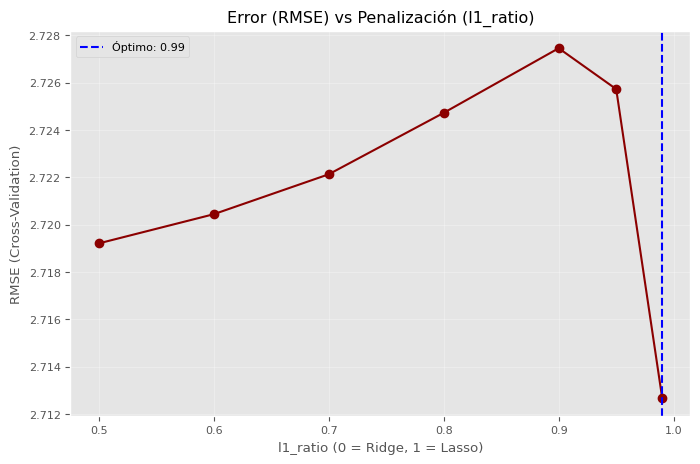

In [52]:
l1_ratio_op_alpha(mod_EN)

In [88]:
alfas_ops = alpha_op(mod_EN)
alpha_op_en, alpha_op_en_1sd = alfas_ops[0], alfas_ops[1]


Alpha Mínimo: 0.000037
Alpha 1-SD: 0.087056 (Este descartará más variables)


In [89]:
# Calculamos la trayectoria de los coeficientes
best_ratio = mod_EN.l1_ratio_
alphas_path, coefs_path, _ = enet_path(X_train,
                                      y_train,
                                       l1_ratio=best_ratio,
                                       alphas = np.logspace(-6, 1, 300)
                                       )

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 7.6116522844240535, tolerance: 6.9737729999999996
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8.099639016349101, tolerance: 6.9737729999999996
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8.34569297706912, tolerance: 6.9737729999999996
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergence

In [90]:
conteo_mod_EN_prio(alpha_op_en,mod_EN, X_train)

--- Resultados del Modelo Elastic Net (l1_ratio=0.99) ---
Alpha óptimo: 0.000037
Número de variables originales: 101
Número de variables finales: 100

Variables que sobrevivieron a la purga:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 'V98', 'V99', 'V100']


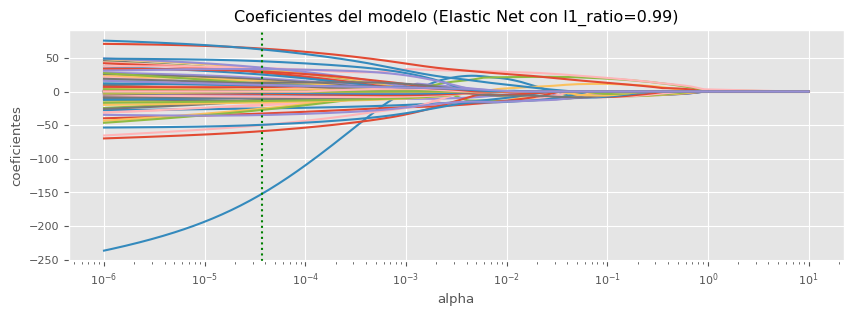

In [91]:
graf_coef_alpha_en(mod_EN,coefs_path, alpha_op_en)
#conclusion el alpha optimo el que reduce al minimo el mse no esta seleccionado, se debe forzar un poco
#es decir sacrificar algo de precicion para ganar seleccion (parsimonia)

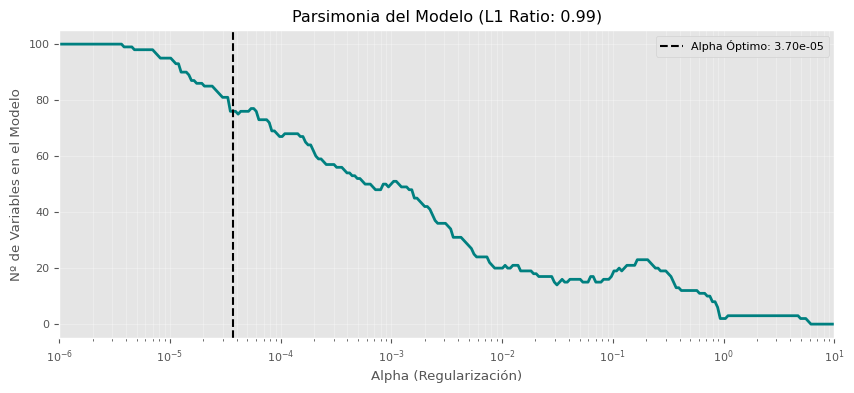

In [92]:
graf_cant_coef_alpha_en(alphas_path,coefs_path, alpha_op_en,best_ratio)
#conclusion el alpha optimo el que reduce al minimo el mse no esta seleccionado, se debe forzar un poco
#es decir sacrificar algo de precicion para ganar seleccion (parsimonia)

In [ ]:
#"Se exploró el espacio de hiperparámetros y el modelo convergió
#consistentemente hacia soluciones con un l1_ratio cercano a 1,
#indicando que una estructura de penalización tipo Lasso es la más
#eficiente para capturar la variabilidad del sistema y reducir la
#dimensionalidad de 100 a 24 predictores."

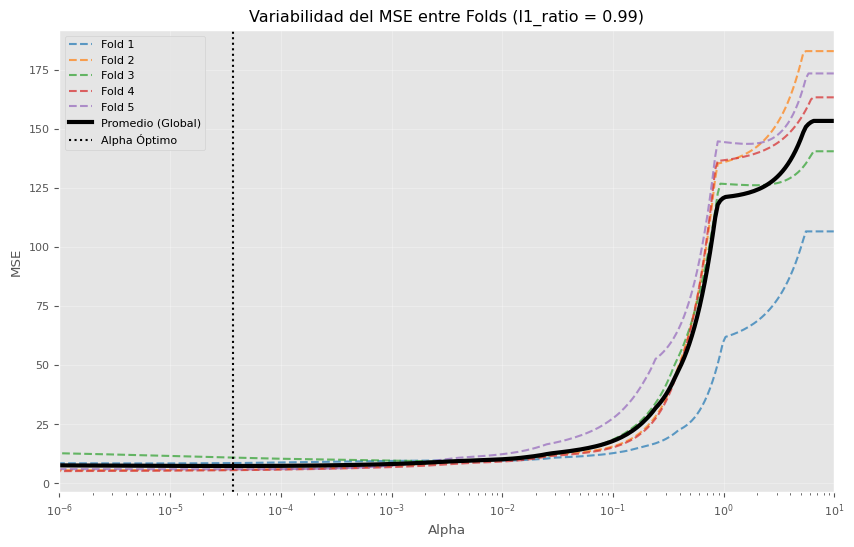

In [93]:
#examinamos los mse calculados para todos los alpha con el l1_ratio optimo
graf_mse_alpha_en(mod_EN, alpha_op_en)

In [99]:
## se escoje nuevo alpha arbitrario para eliminar mas variables
alpha_op_en_nuevo = alpha_op_en_1sd#1e-2#

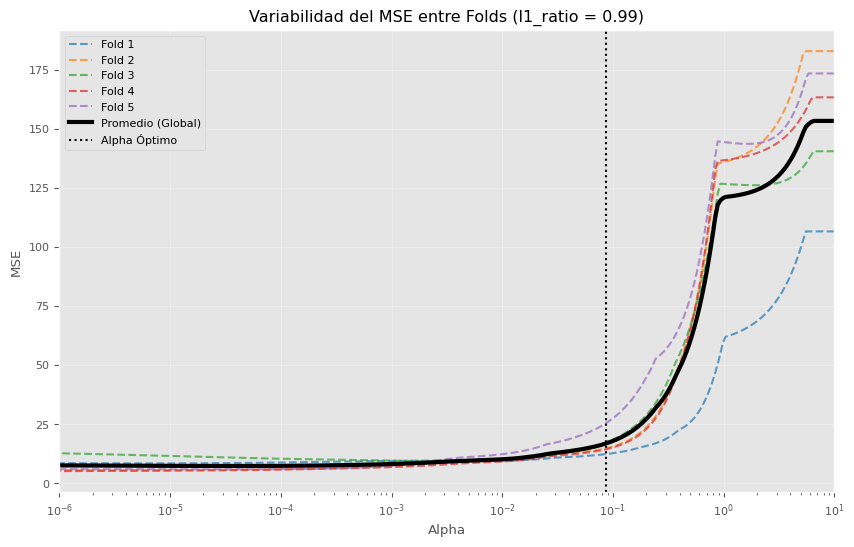

In [95]:
#verificamos la ubicacion del nuevo alpha (mas estricto seleccionara menos variables)
graf_mse_alpha_en(mod_EN, alpha_op_en_nuevo)

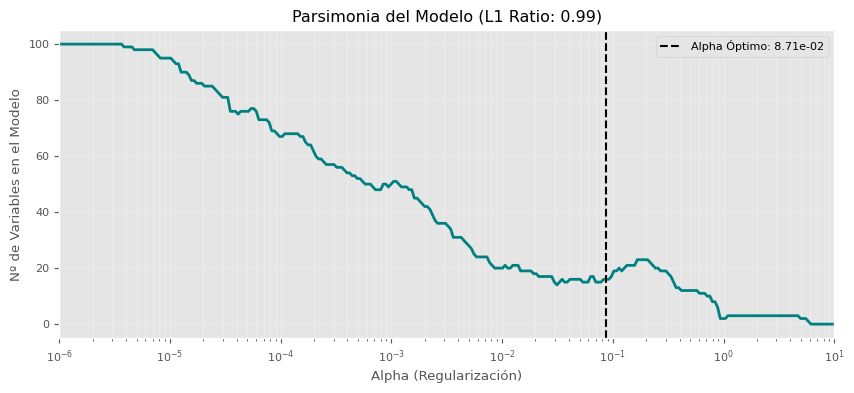

In [100]:
#vemos con cuantas variables nos quedamos
graf_cant_coef_alpha_en(alphas_path,coefs_path, alpha_op_en_nuevo,best_ratio)

In [101]:
#alpha_op_en_nuevo = 1e-2
conteo_mod_EN_post(alpha_op_en_nuevo, alphas_path, coefs_path, X_train)

--- Resultados del Modelo Elastic Net (l1_ratio=0.99) ---
Alpha buscado: 0.087056
Alpha más cercano en el path: 0.087056
Número de variables originales: 101
Número de variables finales: 16

Variables que sobrevivieron a la purga:
['V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V39', 'V40', 'V41', 'V42', 'V51', 'V52', 'V53', 'V54']


In [102]:
##### GENERAMOS MODELO FINAL
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
mod_EN_final = ElasticNet(
    alpha=alpha_op_en_nuevo,
    l1_ratio=0.99,
    max_iter=50000, # Aumenta drásticamente las iteraciones
    tol=1e-8,       # Tolerancia muy estricta
    selection='cyclic' # Fuerza el orden de las variables
)
mod_EN_final.fit(X_train, y_train)

ElasticNet(alpha=0.08705612479099856, l1_ratio=0.99, max_iter=50000, tol=1e-08)

--- Desempeño del Modelo Final en Test ---
RMSE: 3.6909
R² Score: 0.9249
Variables utilizadas: 16
Variables realmente influyentes: 16


/tmp/ipykernel_441/3924610986.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


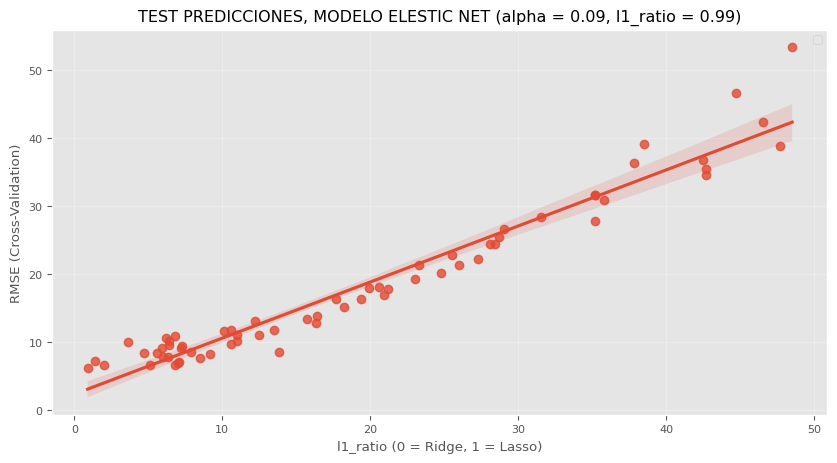

In [103]:
resumen_final(mod_EN_final)

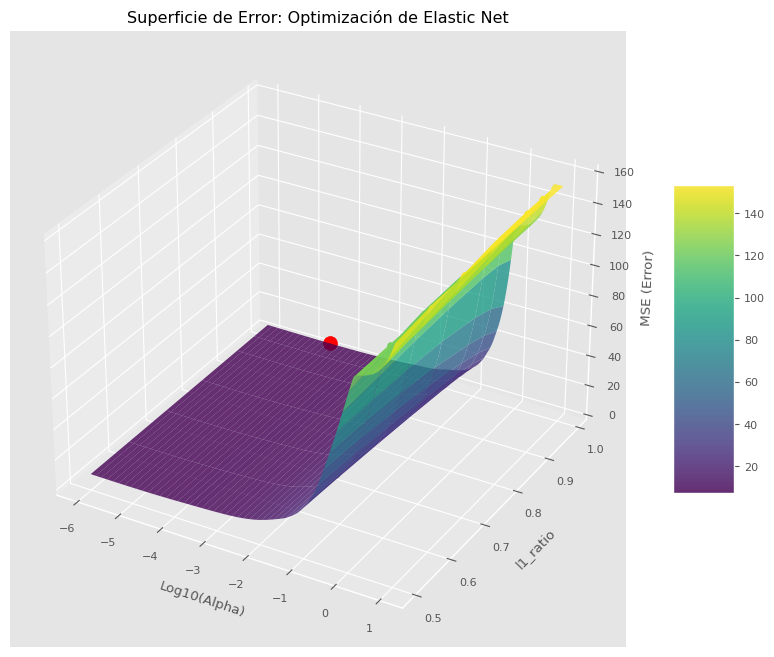

In [104]:
##EST TRANSFORMARLO EN UNA FUNCION
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# 1. Preparar los datos
# mse_path_ tiene forma (n_l1_ratio, n_alpha, n_folds)
mse_avg = np.mean(mod_EN.mse_path_, axis=2)

# Crear la malla (Grid) para el gráfico
# Usamos log10(alpha) para que la superficie no se deforme por los órdenes de magnitud
log_alphas = np.log10(mod_EN.alphas_)
ratios = mod_EN.l1_ratio
X, Y = np.meshgrid(log_alphas, ratios)

# 2. Configurar el gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Dibujar la superficie
surf = ax.plot_surface(X, Y, mse_avg, cmap=cm.viridis,
                       linewidth=0, antialiased=True, alpha=0.8)

# 4. Marcar el punto óptimo
ax.scatter(np.log10(mod_EN.alpha_), mod_EN.l1_ratio_, np.min(mse_avg),
           color='red', s=100, label='Óptimo Encontrado')

# Etiquetas
ax.set_xlabel('Log10(Alpha)')
ax.set_ylabel('l1_ratio')
ax.set_zlabel('MSE (Error)')
ax.set_title('Superficie de Error: Optimización de Elastic Net')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()